# Import

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import DBSCAN

# Load and Scale Dataset

In [8]:

# Load the Iris data set
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:

# Normalize the data
minmaxscaler = MinMaxScaler()
X_scaled = minmaxscaler.fit_transform(df)
X_standardized = StandardScaler().fit_transform(df)


# Knee/Ellbow

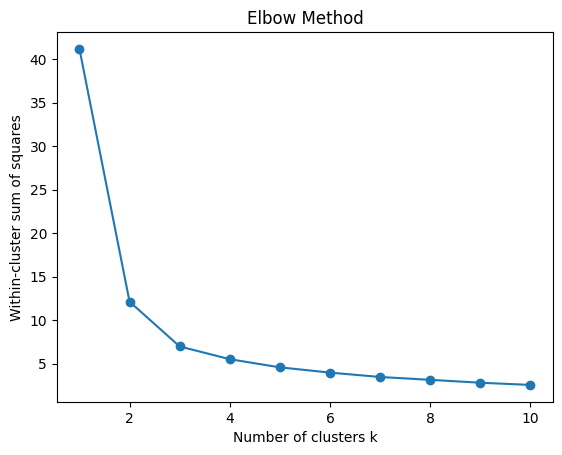

In [10]:
errors = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X_scaled)
    errors.append(model.inertia_)

plt.plot(k_values, errors, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow Method")
plt.show()

# k-means

In [11]:
# "Train" k-means
kmeans = KMeans(n_clusters=3, random_state=42, max_iter=200)
kmeans.fit(X_scaled)

# Add cluster labels to dataframe
df["Prediction"] = kmeans.labels_

# True species hinzufügen, ohne df zu überschreiben
species = [iris.target_names[i] for i in iris.target]
df["species"] = species

# Kreuztabelle
print(pd.crosstab(df["Prediction"], df["species"]))


species     setosa  versicolor  virginica
Prediction                               
0                0          10         42
1               50           0          0
2                0          40          8


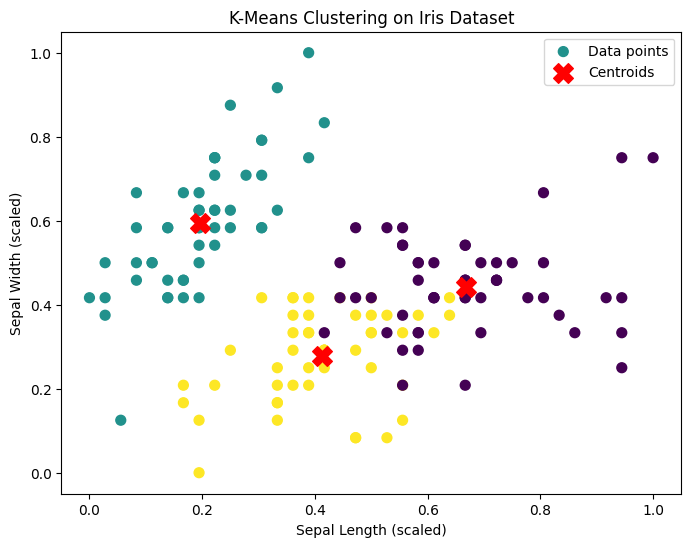

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Prediction species  
0           1  setosa  
1           1  setosa  
2           1  setosa  
3           1  setosa  
4           1  setosa  


In [12]:

# Cluster centers
centers = kmeans.cluster_centers_

# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap="viridis", s=50, label="Data points")
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="X", label="Centroids")

plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.title("K-Means Clustering on Iris Dataset")
plt.legend()
plt.show()

# Print results
print(df.head())



# Hirachical clustering

In [13]:
# Hierarchical clustering with average linkage
Z = linkage(X_scaled, method="complete", metric="euclidean")

# Choose the number of desired clusters
k = 3

# Determine the distance threshold that cuts the dendrogram into k clusters
# Z contains the hierarchical merges 
#Die Merge-Distanzen in Z sind in aufsteigender Reihenfolge gespeichert: frühe Merges haben kleine Distanzen, späte Merges große Distanzen. 
#Wenn du am Ende genau k Cluster haben willst, dann musst du den Dendrogramm-Schnitt kurz vor den letzten k-1 Zusammenführungen setzen.
#Für k = 3 heißt das: kurz vor den letzten 2 Merges also in der Nähe der zweitletzten Merge-Höhe 
# The column with index 2 stores the merge distances
threshold = Z[-(k - 1), 2]

# maxclust means: form exactly k clusters
clusters = fcluster(Z, t=k, criterion="maxclust")

print("Cluster labels:")
print(clusters)


# Convert numeric target values into species names
species = [iris.target_names[i] for i in iris.target]

# Create a small DataFrame for comparison
df_compare = pd.DataFrame({
    "cluster": clusters,
    "species": species
})

print("\nCluster vs. true species:")
print(pd.crosstab(df_compare["cluster"], df_compare["species"]))



Cluster labels:
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 2 1 1
 2 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 2 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2]

Cluster vs. true species:
species  setosa  versicolor  virginica
cluster                               
1             0           1         33
2             0          49         17
3            50           0          0


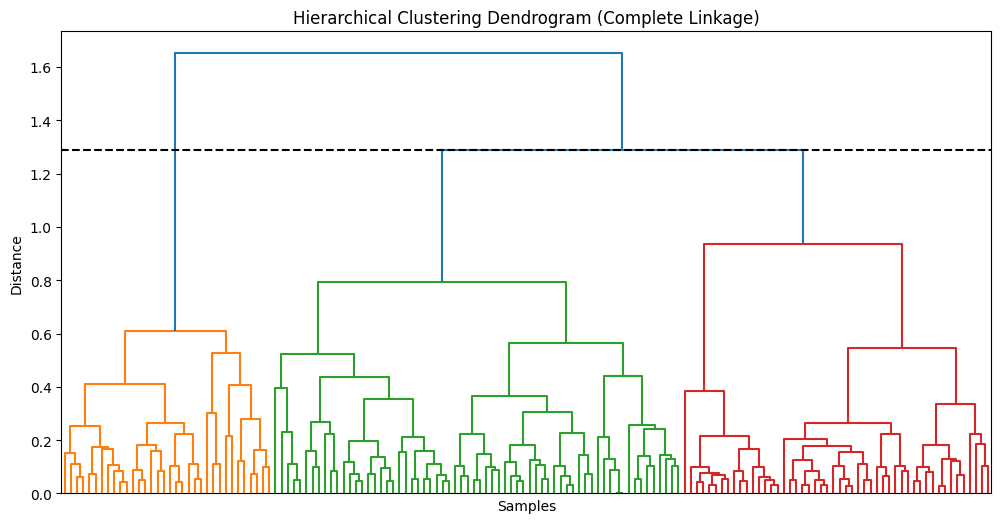

In [14]:
# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    no_labels=True,           # hide sample labels for readability
    color_threshold=threshold # color branches below the cut threshold
)

# Draw a horizontal line to show where the dendrogram is cut
plt.axhline(y=threshold, color="black", linestyle="--")

plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()




# DBSCAN

In [15]:
# Apply DBSCAN
model = DBSCAN(eps=0.5, min_samples=4)
labels = model.fit_predict(X_standardized)

# Put results into a table
df = pd.DataFrame(X_standardized, columns=iris.feature_names)
df["species"] = species
df["cluster"] = labels

print(df.head())
print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())

print("\nCluster vs true species:")
print(pd.crosstab(df["cluster"], df["species"]))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   
3          -1.506521          0.098217          -1.283389         -1.315444   
4          -1.021849          1.249201          -1.340227         -1.315444   

  species  cluster  
0  setosa        0  
1  setosa        0  
2  setosa        0  
3  setosa        0  
4  setosa        0  

Cluster counts:
cluster
-1    33
 0    45
 1    72
Name: count, dtype: int64

Cluster vs true species:
species  setosa  versicolor  virginica
cluster                               
-1            5          10         18
 0           45           0          0
 1            0          40         32


C:\Users\chris\AppData\Local\Temp\ipykernel_11664\641830404.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


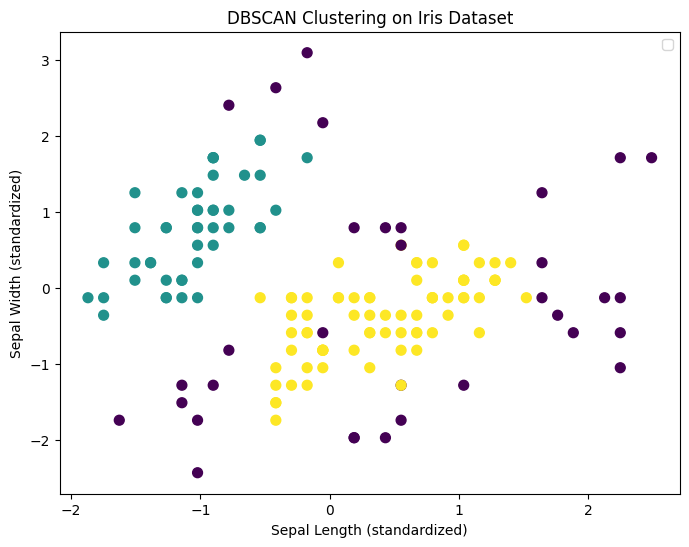

In [16]:
# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_standardized[:, 0], X_standardized[:, 1], c=model.labels_, cmap="viridis", s=50)

plt.xlabel("Sepal Length (standardized)")
plt.ylabel("Sepal Width (standardized)")
plt.title("DBSCAN Clustering on Iris Dataset")
plt.legend()
plt.show()